<a href="https://colab.research.google.com/github/deepan98raj-dotcom/git_notes_/blob/main/25_Session_Emsemble_Learning_%26_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ensemble learning is a machine learning technique that combines the predictions from multiple individual models to create a single, more accurate,and more robust prediction

To understand what emsemble learning, is think of it as the 'wisdom of the crowd'.Instesd of replying on single,complex machine learning model to make a prediction you combine the outputs of many individual,simpler models to form a stronger, accurate prediction

**Ideology:** Think of it like this: If you have a different decision to make, are you better off asking one expert for their opinion, or asking a panel of five experts and taking a vote? Usually the group's collective wisdom is more reliable than any single person guess.Emsemble learning applies this exact same logic to data.

The problem:
To understand ensemble learning, we first need to understand the constraints of indivivals models,which are often analyzed through the lens of the Bias-Variance Tradeoff

**High Bias (Underfitting)** : Simple models (like a shallow decision tree) might be too basic. They fail to capture the underlying patterns in data, leading to poor performance on both training and testing data.

**High Variance (Overfitting)** : Complex models (like a very deep, unconstrained decision tree) might learn the training data 'too well,' including its noise and outliers. while they perform perfectly on training data, they fail to generalize to new unseen data.

**SOLUTION**: Why we use Ensembles?

Ensemble methods are designed specifically to balance this tradeoff by strategically combining models.

**Reducing Error**: By combining multiple models, the errors  made by individual often cancel each other out. if one model makes an overly optimistic prediction and anthor makes an ovely pessimistic one their average is likely to be much closer to the truth.

**increased Robustness**: Single models, particularly decision trees, are often highly sensitve to small changes in the training on different subset or through sequential correction, create a more stable,'robust' prediction

# The three Main Strategies:

There are three primary ways to build an ensemble. You can think of these as different ways to organize your 'panel of experts'.

1.**Bagging**:
The Voting approch in Bagging, you train multiple versions of the same type of model in parallel. each model is trained on slightly different random subset of your data.

How it works: take your data, create several random samples (with replacement),and train a model on each. When it's time to predict all models 'vote', and the majority wins.

Famous Example: Random forest. It builds many decision trees and lets them vote on the final outcome.

2.**Boosting**:
The **learning from mistakes** Approch Boosting is sequential. instead of voting,each new model tries to fix the mistakes made by the previous one.

How it works: The first model makes predictions. the next model focuses heavily on the data points the first model got wrong.This continues, with each new model paying more attention to the 'difficult' cases.

Famous Examples: AdaBoost, XGBoost, and LightGBM.There ara often considered some of the most powerfull algorithms for structured
data.

3.**Stacking**:
 The **Manager approch** stacking uses a diifernt stategy: you train severval different types of models(eg., a Deecision Tree, a Support vector Machine, and a Linear Regression model). Then you train one final 'meta-model' to look at all those results and decide how to weigh them.

How it work: Think of the first layer as the workers and the second layer as the 'manager' who learns which workers are most reliable.  

A Simple Analogy : Choosing a Movie:

Single Model: You pick a movie based on one friend's recommendation. They might have bad taste!

Bagging: You ask10 friends to pick a movie. you watch the one most people suggested.(You are less likely to end up with a bad movie).

Boosting: You ask a friend for a recommendation.If you don't like it, you go to a second friend and say, "The last guy suggested a horror movie, which i hated.Don't suggest horror."the second friend learns fron the first one's failure.

Stacking: You ask an accountant an film critic, and a child for a movie recommendation. then you use your own experience to decide whose opinion you trust most for that specific genre.


Mean Squared Error is a common method used to measure how far off your model's predictions are from the actual values.

Since ensemble methods like Random Forest or Gradient Boosting are often used for regression (predicting continous numbers like house price), they need a way to quantify their 'error' so they can learn to improve.

How MSE Works?
Mathematically, the MSE is calculated by taking the difference between the actual value(y) and the predicted value (y), squaring that difference and then averaging it across all your data points.

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Why we use the 'Squared' part?

there are two critical reasons why we square the errors:

Penalizing Large Mistakes: Because we square the error, a prediction that is "way off" is penalized much more heavily than a prediction that is "slightly off"

This forces the ensemble to focus on getting the big, Expensive mistakes right.

Removing Negative Signs: Since a predictions can be either higher or lower than the actual value,simply adding the errors would cause them to cancel each other out (positive and negative errors would sum to zero) Squaring ensures every error is positive.

The role of MSE in Ensemble Learning:

In random Forest(bagging) : The MSE acts as the evalutor. The trees built to minimize this error. When you see your model's performance report (like the MSE value in your code results),it is telling you the average 'squared' distance between your model's guess and the truth.

In ensemble learning $R^2$ is a statistical metric that tells you how well your model explains the varitions in your data.

Unlike Mean squared Error (MSE), which measures the magnitude of errors in units(like dollars for house prices), $R^2$ provide a standardized score that is easy to interpret.

How to Understand $R^2$ score usually ranges from 0 to 1:

Imagine you give your students a test, and they get all different kinds of marks. This mix of marks is the total variation(or total confusion).

**1. Just Guessing the average:**
  * Suppose the class average is 50 marks, if you don't know a student's score, you just blindly guess that everyone got 50. This is your baseline guess.

**2. Your Model's Prediction:**
  * Instead of a blind guess, your model looks at how much the student studied and makes a smart guess about their score. this leaves
  a much smaller error.

# What $R^2$ Means:

$R^2$ check how much better your model is compared to that blind average guess:
* If you get $R^2$ = 0.85, it means your model successfully fixed or cleared away 85% of the confusion/ingorance that you would have had if you just made a blind guess!



Step 1 : Environment & Dataset Loading

We will use the California Housing dataset from scikit-learn because it is clean, industry-standard, and perfect for teching.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

# 1. Load Data
housing = fetch_california_housing(as_frame=True)
df = housing.frame

#Quick view
print(df.head())
print(df.info())
print(df.describe())
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population

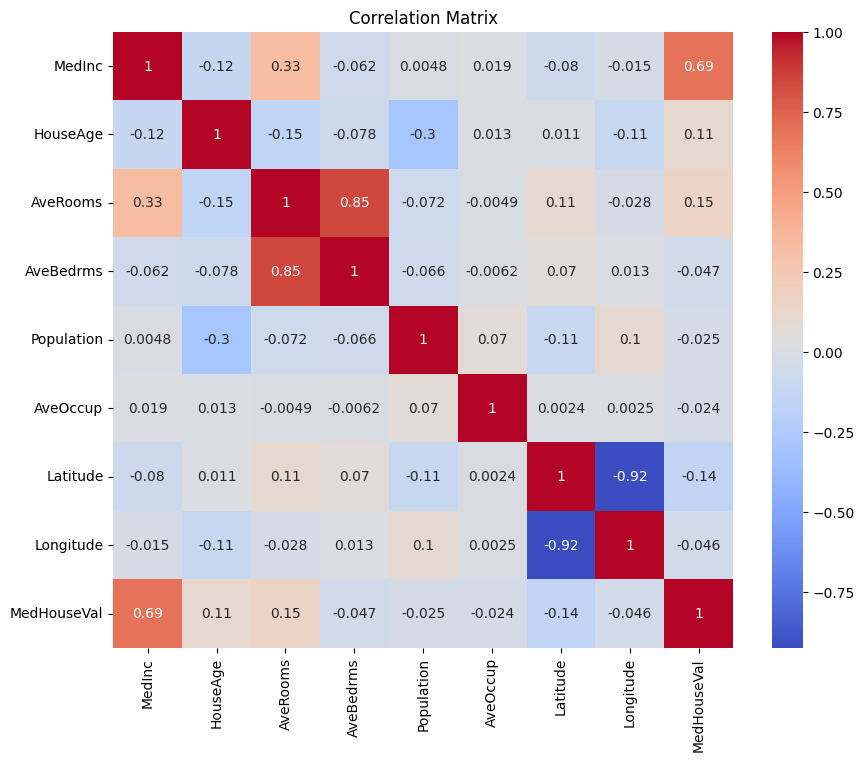

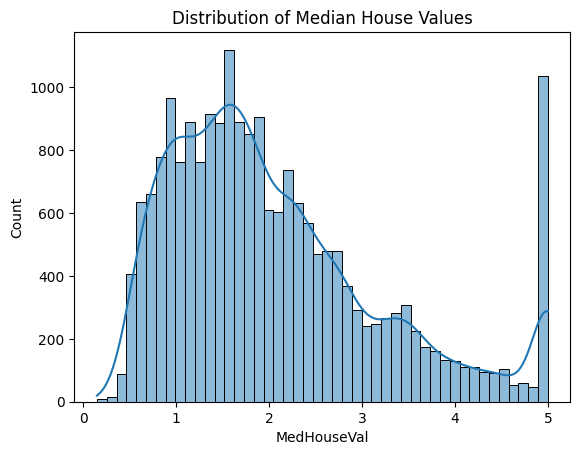

In [ ]:
# 2. EDA Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# 3. Target Distribution
sns.histplot(df['MedHouseVal'], kde=True)
plt.title('Distribution of Median House Values')
plt.show()



In [ ]:
# prepare Data

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate_model(model,name):
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  print(f'---{name}results ---')
  print(f'MSE: {mse:.4f} | R^2 Score: {r2:.4f}\n')

# 1. Baseline: Single Decision tree
tree = DecisionTreeRegressor(random_state=42)
evaluate_model(tree, 'Single Decision Tree')

# 2. Upgrade: Random Forest (Bagging)
rf = RandomForestRegressor(random_state=42)
evaluate_model(rf, 'Random Forest')

# 3. Upgrade: Gradient Boosting (Boosting)
gb = GradientBoostingRegressor(random_state=42)
evaluate_model(gb, 'Gradient Boosting')

---Single Decision Treeresults ---
MSE: 0.4952 | R^2 Score: 0.6221

---Random Forestresults ---
MSE: 0.2554 | R^2 Score: 0.8051

---Gradient Boostingresults ---
MSE: 0.2940 | R^2 Score: 0.7756



**Comparision**

Why did the Random Forest (RF) beat the Decision Tree (DT)? why did gradient Boosting (GB) perform differently than the RF?

Decision Tree: it's Brittle it made a choice based on a single path of logic. It has high variance.

Random Forest: It smoothed out the errors by averaging many trees. It reduced variance.

Gradient Boosting: it tried to learn from errors, but perhaps it didn't optimize as well as the RF on this specific dataset.



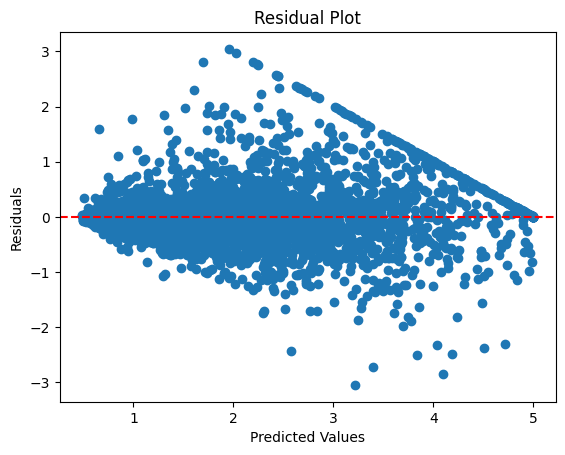

In [ ]:
# Calculate reiduals

residuals = y_test - rf.predict(x_test)

# Visualize
plt.scatter(rf.predict(x_test), residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()


# Random Forest

To understand Random Forest, it is best to think of it as a democratic voting system. instead of asking one person (Single Decision Tree) to make a high-stakes decision, you gather a large group of persons, have them vote,and take the majority opiion

The Decision tree before diving into the **Random Forest you must understand the Decision tree

The Concept: A Decision Tree is like a flow chart.It asks a series of 'yes/no' questions(eg., 'is the square footage greater than 1,500?)

The Limitation: A single tree is often 'brittle'. if you change just a few data points in your training set, the entire structure of the tree can change drastically. This is known as high variance - the model is too sensitive to the specific noise in its training data.

Random Forest is a Bagging(Bootstrap Aggregating) technique. it solves the 'brittleness' of single tree by creating a massive collection of them and averaging their results.

It uses two specfic types of 'randomness' to ensure the trees don't all act the same:

**A**. Randomness in Data (Bagging):

Instead of training every tree on the entire dataset, Random forest create a 'bootstrapped' sample for each tree. It pulls data points from your original set with replacement ( meaning the same data point can appear multiple times in one sample). Because each tree sees

**B**. Randomness in features:
when a standard Decision Tree makes a split, it looks at every available features to find the best one. A random Forest does something
different at each node, it only considers a random subset of features.

Why? This prevents one very dominant feature from cotrolling every single tree in the forest. It forces the trees to explore different relationships in the data, ensuring the final 'crowd' is diverse.  

How the Random Forest Makes a Decision ?
Once you have trained, for example 100 different trees, you have a forest.

For Classification: The forest takes a majority vote.if 70 trees say 'NO', the forest predicts 'YES'

For regression (predicting numbers): The forest takes the average of all the trees' predictions

To demonstrate the power of the random forest algorithm, we will use the **Breast Cancer Wisconsin (Diagnostic) Dataset provided by sciki-learn

**Goal** : To determine if a tumor is Malignant (harmful) or Benign (harmless) based on 30 numerical features (like radius, texture, and smoothness) measured from cell nulei.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Load the Dataset
data = load_breast_cancer(as_frame=True)
df = data.frame

# Quick View
print(df.head())
print(df.info())
print(df.describe())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

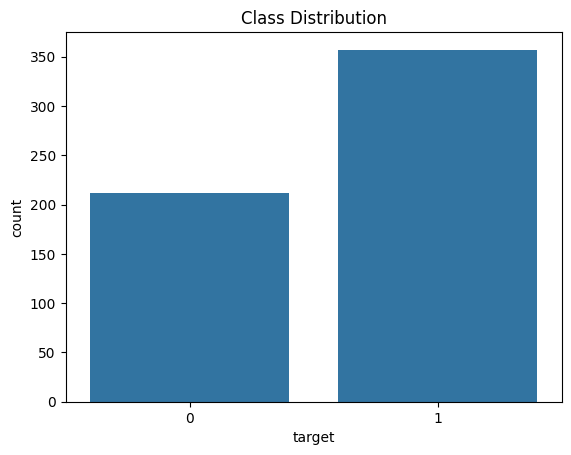

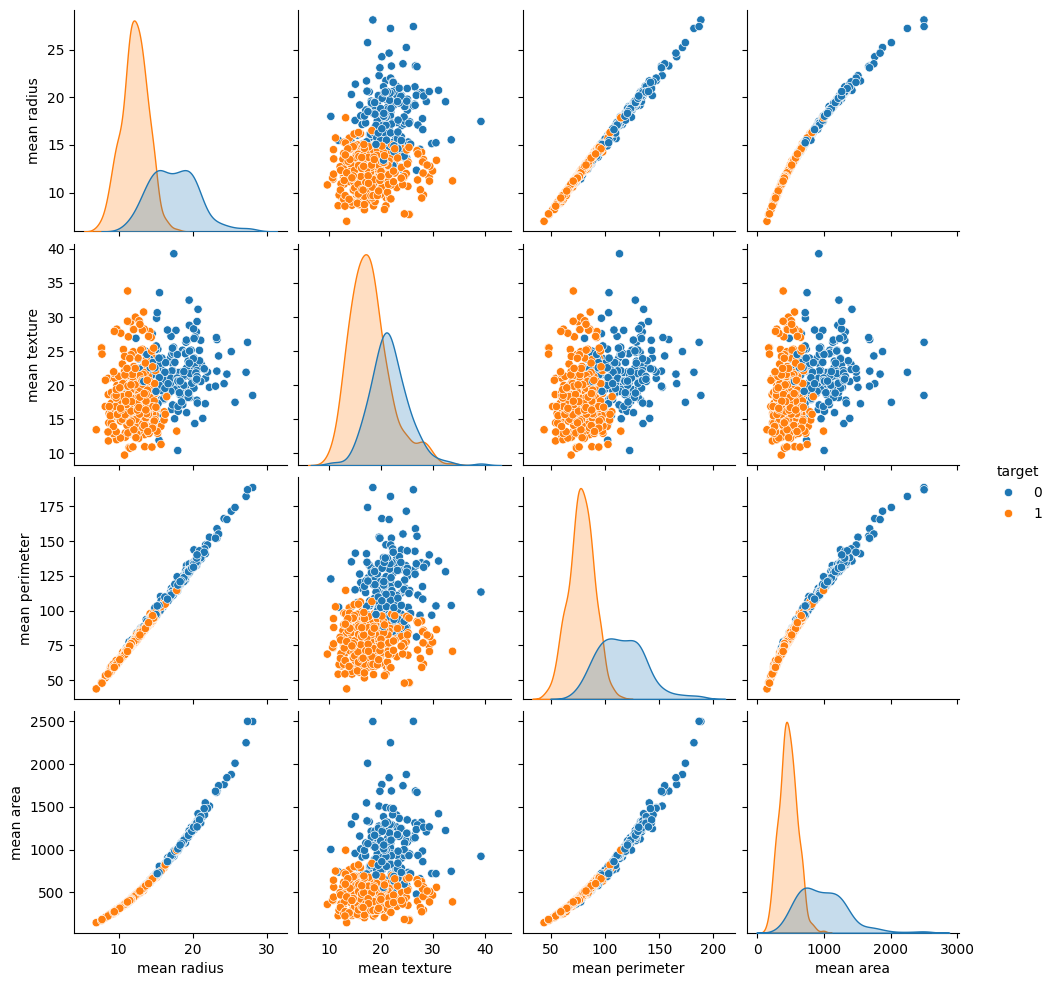

In [ ]:
# 1. Check Class Balance
#.corr()

sns.countplot(x='target', data=df)
plt.title('Class Distribution')
plt.show()

# 2. Visualize Feature correlation
features_mean = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'target']
sns.pairplot(df[features_mean],hue = 'target', diag_kind='kde')
plt.show()



In [ ]:
# Split the data
X = df.drop('target', axis=1)
y = df['target']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
print(rf)

# Make predictions
y_pred = rf.predict(x_test)
print(y_pred)

# Evaluate
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))




RandomForestClassifier(random_state=42)
[1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0]
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

[[40  3]
 [ 1 70]]
